# Feature Correlations

Correlation structure, predictive signal proxies, and multicollinearity risks.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "agents.md").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate project root from notebook directory.")
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 120
pd.options.display.max_rows = 50

from data_analysis._shared.eda_utils import (
    ENRICHED_PATH,
    FEATURE_GROUPS,
    NUMERIC_OUTLIER_COLUMNS,
    build_enriched_tasks,
    categorical_variants,
    cross_sheet_consistency_report,
    detect_outliers,
    diagnose_client_unmatched,
    diagnose_pair_unmatched,
    diagnose_schedule_unmatched,
    dtype_audit,
    exact_duplicates,
    join_datasets,
    load_all_data,
    load_enriched_tasks,
    missing_summary,
    missingness_by_group,
    missingness_correlation,
    near_duplicates_data,
    proofread_reviewer_comparison,
    same_language_examples,
    same_language_report,
    set_plot_style,
    sheet_dimensions_report,
    summarize_join_integrity,
    timestamp_logic_report,
    timestamp_violation_samples,
    translator_on_time_summary,
    translator_quality_summary,
    wilson_interval,
    zero_value_report,
)

set_plot_style()
sheets = load_all_data()
data = sheets["data"]
schedules = sheets["schedules"]
clients = sheets["clients"]
pairs = sheets["pairs"]
print(f"Loaded Data={data.shape}, Schedules={schedules.shape}, Clients={clients.shape}, Pairs={pairs.shape}")

Loaded Data=(997933, 29), Schedules=(983, 11), Clients=(2645, 6), Pairs=(4688, 7)


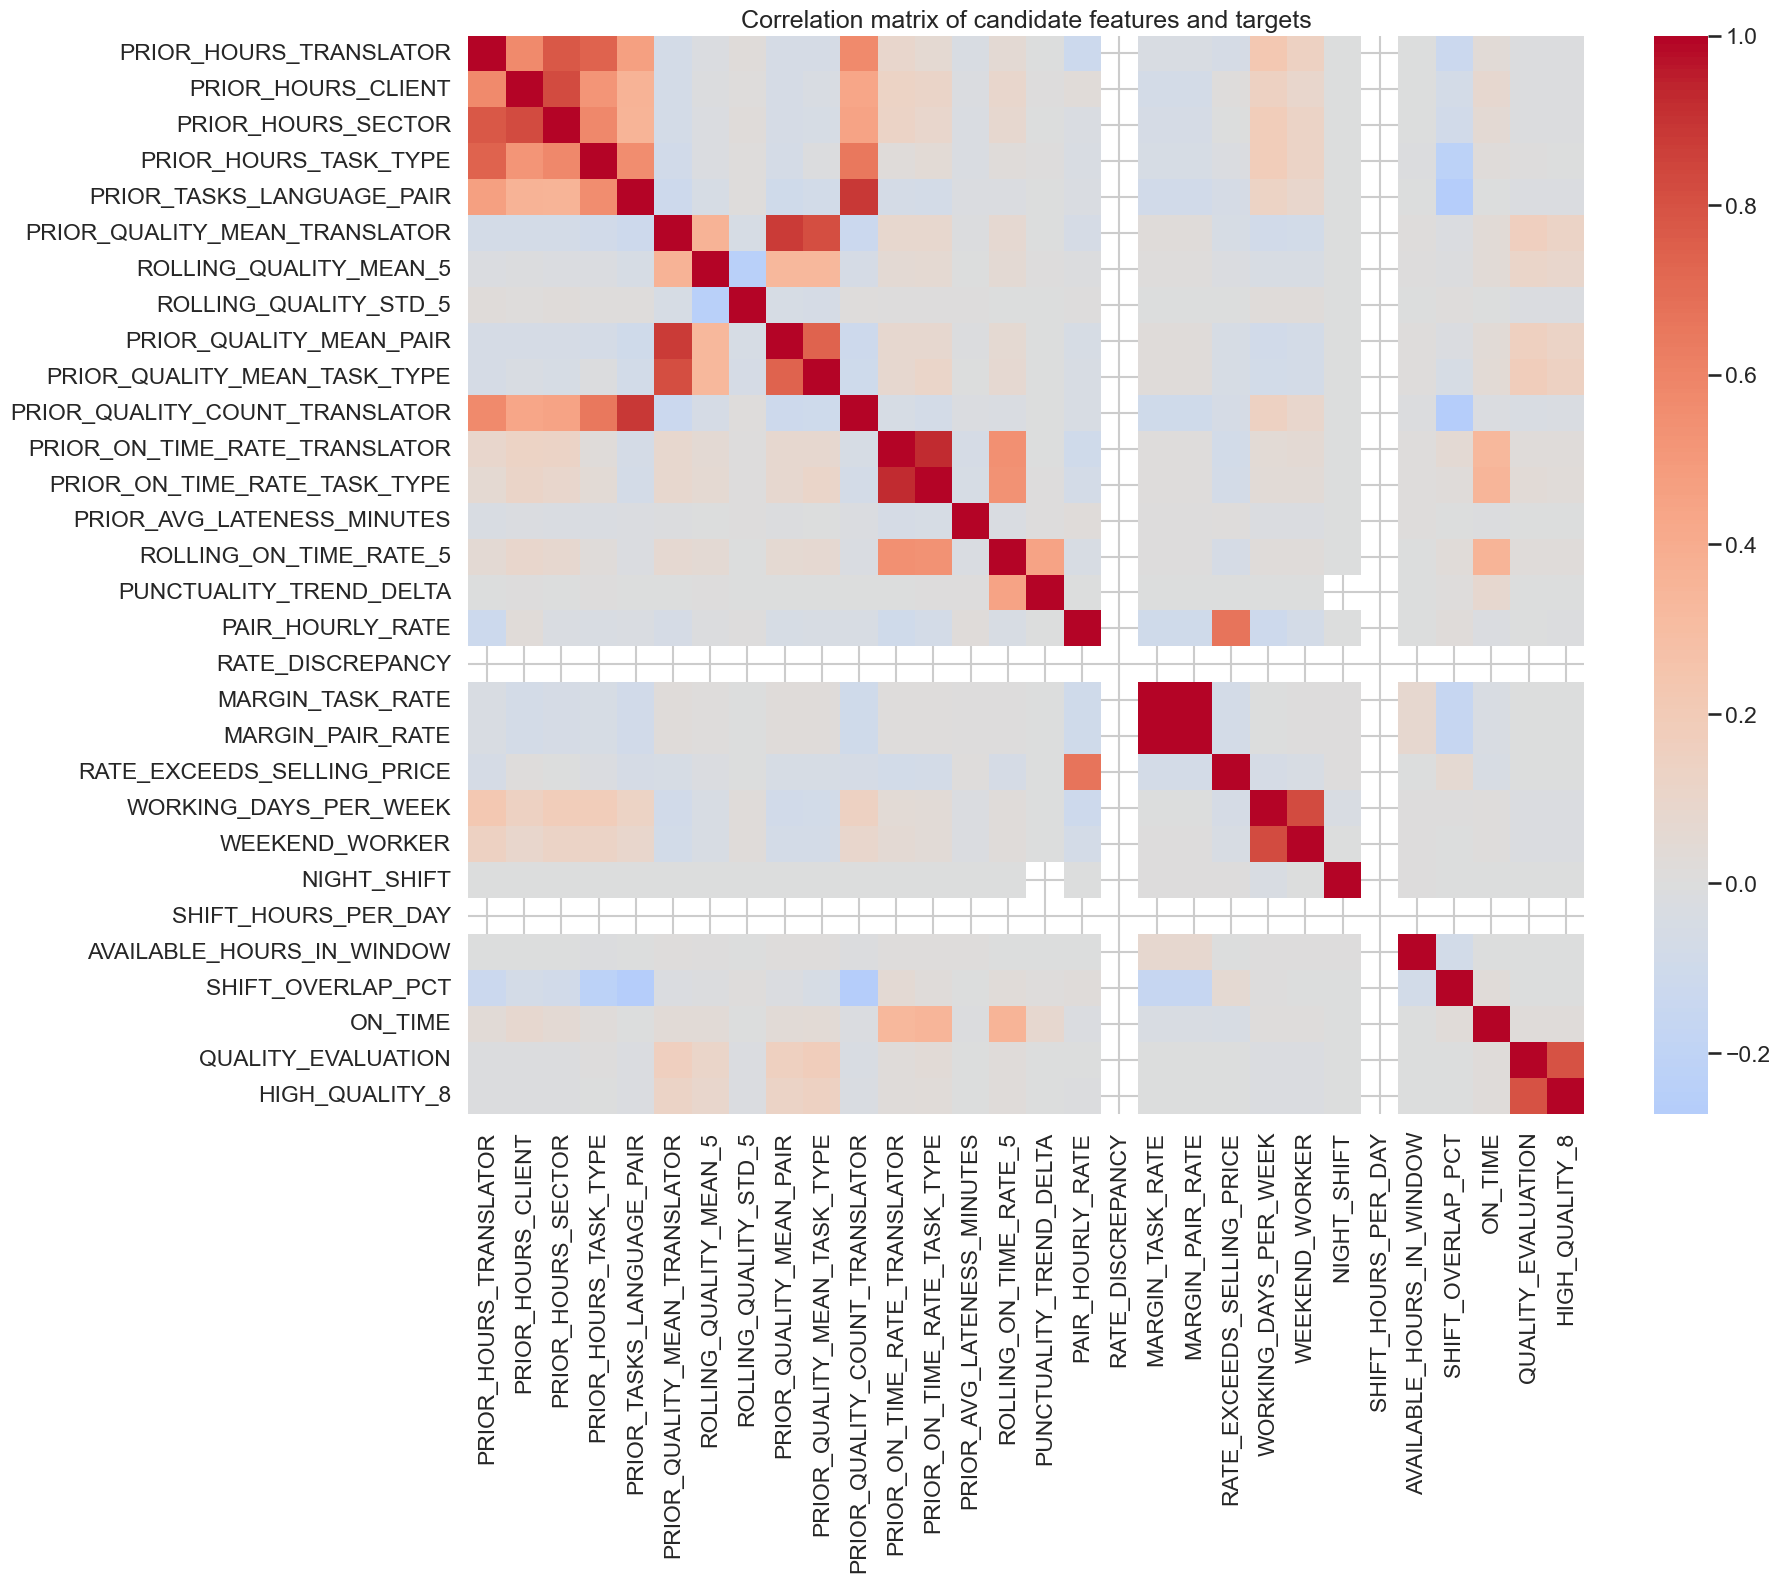

In [2]:
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

enriched = load_enriched_tasks()
candidate_features = []
for columns in FEATURE_GROUPS.values():
    candidate_features.extend(columns)
candidate_features = list(dict.fromkeys(candidate_features))

numeric_frame = enriched[candidate_features + ["ON_TIME", "QUALITY_EVALUATION", "HIGH_QUALITY_8"]].apply(pd.to_numeric, errors="coerce")
corr = numeric_frame.corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix of candidate features and targets")
plt.show()

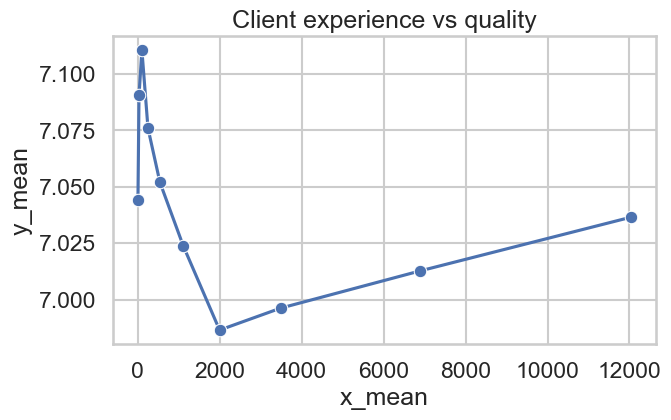

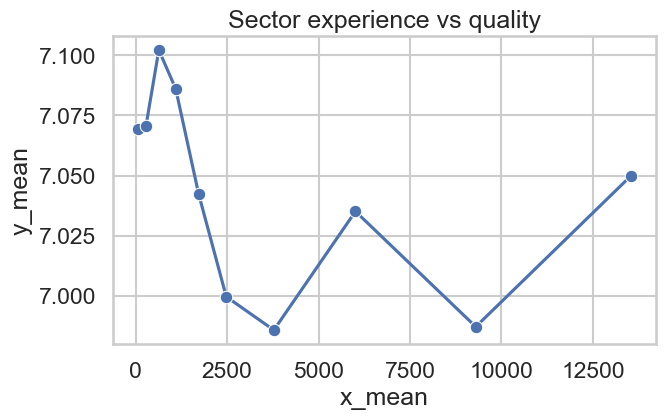

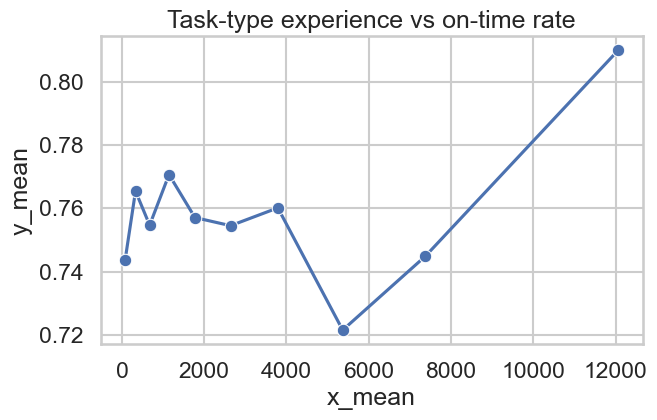

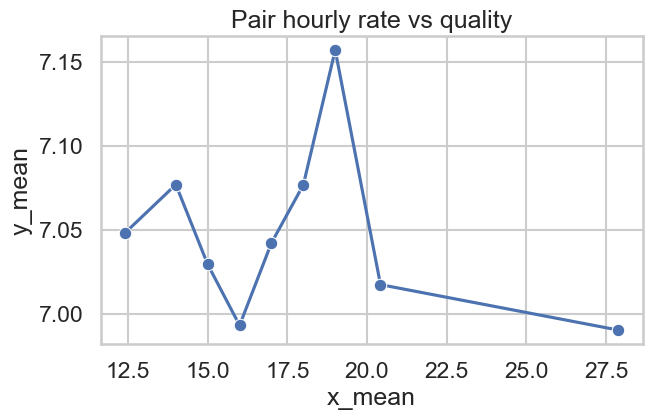

In [3]:
def binned_average_plot(df, x_col, y_col, title):
    subset = df[[x_col, y_col]].dropna().copy()
    if subset.empty:
        return
    subset["bin"] = pd.qcut(subset[x_col], q=10, duplicates="drop")
    summary = subset.groupby("bin").agg(x_mean=(x_col, "mean"), y_mean=(y_col, "mean")).reset_index(drop=True)
    plt.figure(figsize=(7, 4))
    sns.lineplot(data=summary, x="x_mean", y="y_mean", marker="o")
    plt.title(title)
    plt.show()

binned_average_plot(numeric_frame, "PRIOR_HOURS_CLIENT", "QUALITY_EVALUATION", "Client experience vs quality")
binned_average_plot(numeric_frame, "PRIOR_HOURS_SECTOR", "QUALITY_EVALUATION", "Sector experience vs quality")
binned_average_plot(numeric_frame, "PRIOR_HOURS_TASK_TYPE", "ON_TIME", "Task-type experience vs on-time rate")
binned_average_plot(numeric_frame, "PAIR_HOURLY_RATE", "QUALITY_EVALUATION", "Pair hourly rate vs quality")

In [4]:
feature_matrix = numeric_frame[candidate_features].copy()
feature_matrix = feature_matrix.fillna(feature_matrix.median(numeric_only=True))

valid_on_time = numeric_frame["ON_TIME"].notna()
mi_on_time = mutual_info_classif(
    feature_matrix.loc[valid_on_time],
    numeric_frame.loc[valid_on_time, "ON_TIME"].astype(int),
    random_state=42,
)
mi_high_quality = mutual_info_classif(
    feature_matrix.loc[numeric_frame["HIGH_QUALITY_8"].notna()],
    numeric_frame.loc[numeric_frame["HIGH_QUALITY_8"].notna(), "HIGH_QUALITY_8"].astype(int),
    random_state=42,
)
mi_quality = mutual_info_regression(
    feature_matrix.loc[numeric_frame["QUALITY_EVALUATION"].notna()],
    numeric_frame.loc[numeric_frame["QUALITY_EVALUATION"].notna(), "QUALITY_EVALUATION"],
    random_state=42,
)

mi_summary = pd.DataFrame(
    {
        "feature": candidate_features,
        "mi_on_time": mi_on_time,
        "mi_high_quality": mi_high_quality,
        "mi_quality_continuous": mi_quality,
    }
).sort_values("mi_quality_continuous", ascending=False)
display(mi_summary)

,feature,mi_on_time,mi_high_quality,mi_quality_continuous
9,PRIOR_QUALITY_MEAN_TASK_TYPE,0.009621,0.012144,0.027165
8,PRIOR_QUALITY_MEAN_PAIR,0.007181,0.008408,0.022233
5,PRIOR_QUALITY_MEAN_TRANSLATOR,0.009415,0.008481,0.020083
6,ROLLING_QUALITY_MEAN_5,0.014191,0.017935,0.019078
0,PRIOR_HOURS_TRANSLATOR,0.016892,0.001977,0.007475
2,PRIOR_HOURS_SECTOR,0.015118,0.000823,0.006237
12,PRIOR_ON_TIME_RATE_TASK_TYPE,0.063442,0.002177,0.006206
3,PRIOR_HOURS_TASK_TYPE,0.014432,0.001019,0.005731
11,PRIOR_ON_TIME_RATE_TRANSLATOR,0.057611,0.002071,0.004362
13,PRIOR_AVG_LATENESS_MINUTES,0.021740,0.001170,0.004077


In [5]:
corr_candidates = numeric_frame[candidate_features].corr().abs()
upper_triangle = corr_candidates.where(np.triu(np.ones(corr_candidates.shape), k=1).astype(bool))
highly_correlated = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "abs_correlation"})
    .query("abs_correlation >= 0.8")
    .sort_values("abs_correlation", ascending=False)
)
display(highly_correlated)

,feature_a,feature_b,abs_correlation
271,MARGIN_TASK_RATE,MARGIN_PAIR_RATE,1.000000
209,PRIOR_ON_TIME_RATE_TRANSLATOR,PRIOR_ON_TIME_RATE_TASK_TYPE,0.921029
95,PRIOR_TASKS_LANGUAGE_PAIR,PRIOR_QUALITY_COUNT_TRANSLATOR,0.889633
112,PRIOR_QUALITY_MEAN_TRANSLATOR,PRIOR_QUALITY_MEAN_PAIR,0.880644
24,PRIOR_HOURS_CLIENT,PRIOR_HOURS_SECTOR,0.819387
289,WORKING_DAYS_PER_WEEK,WEEKEND_WORKER,0.816579
113,PRIOR_QUALITY_MEAN_TRANSLATOR,PRIOR_QUALITY_MEAN_TASK_TYPE,0.815571
